# T30 — Inclination shallowing meets plate reconstruction: a corrected sedimentary paleolatitude on a reconstructed site

**Apply the King (1955) inclination-shallowing correction with a published flattening factor (Gilder et al. 2001, f ≈ 0.55) to a tabulated Asian Jurassic sedimentary site, reconstruct the same site through Cao 2024 to its rock age, and compare uncorrected paleolat, corrected paleolat, and reconstructed paleolat in one four-bar figure.**

## What this notebook produces

For a single sedimentary site (Junggar basin, central Asia, 160 Ma) we compute:

1. The **uncorrected paleolatitude** from the raw Fisher-mean inclination (axial-dipole formula `tan(I) = 2·tan(λ)`).
2. The **shallowing-corrected paleolatitude** after unflattening with `tan(I_corr) = tan(I_obs) / f`, using the Gilder et al. (2001) published `f ≈ 0.55` for these red beds.
3. The **reconstruction-predicted paleolatitude** at the same site at 160 Ma in Cao 2024.

These are charted side by side together with the predicted–corrected residual, so the user can see whether ignoring shallowing biases the paleolat by an amount that matters for the reconstruction comparison. For Junggar Jurassic the uncorrected paleolat is ~16°N; with `f = 0.55` the corrected paleolat is ~28°N — a 12° shift that is large compared to typical 5° model-data residuals.

**Audience**: postgrad.
**Difficulty**: ★★★.

## Learning objectives

- Apply the King (1955) inclination-shallowing correction with a fixed published `f` and see the resulting paleolatitude shift.
- Reconstruct a single sedimentary site to its rock age with `gplately` and compare against the corrected paleomagnetic paleolatitude.
- Surface the four-way comparison (uncorrected / corrected / reconstruction / residual) on one pyGMT figure.
- Recognise where a full elongation-inclination (E/I) optimisation (Tauxe & Kent 2004) would be required if `f` were not already published — and which step in the notebook would need to be replaced.

## Prerequisites and runtime

- Plate model: Cao 2024 default.
- Python: `gplately`, `pygmt`, `pygplates`, `numpy`, `pandas`.
- Bundled data: `data/paleomag/gilder2001_asian_seds.csv`.
- Runtime: a few seconds end-to-end.


In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change site + age + dataset here

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME       = "Cao2024"
DATA_CSV         = "data/paleomag/gilder2001_asian_seds.csv"
SITE_LON_LAT     = (107.0, 40.5)  # Junggar basin, central Asia (Gilder 2001 sampling area)
ROCK_AGE_MA      = 160.0          # mid-point of Jurassic sediments
F_FLATTENING     = 0.55           # King (1955) factor; 0.55 per Gilder et al. 2001
# ============================================================================


## 1. Load the sedimentary inclination data

In [3]:
# Cell 2 — load data
sites = pd.read_csv(DATA_CSV, comment="#")
print(f"loaded {len(sites)} sedimentary site directions")
sites.head()


loaded 42 sedimentary site directions


,site_id,lon,lat,dec,inc,n_specimens,k,a95
0,GD001,106.951,40.396,17.7,28.3,7,146.0,6.2
1,GD002,107.284,41.486,12.5,31.9,7,45.3,11.2
2,GD003,108.052,41.006,29.7,28.4,7,110.7,7.1
3,GD004,107.774,39.679,6.3,39.7,8,92.8,7.9
4,GD005,105.769,40.496,344.7,37.3,8,100.6,7.6


## 2. King (1955) inclination-shallowing correction

We unflatten the Fisher-mean observed inclination via `tan(I_corr) = tan(I_obs) / f` with the published Gilder et al. (2001) flattening factor `f ≈ 0.55`, then convert to paleolatitude via the dipole formula. A full elongation-inclination (E/I) optimisation against the TK03.GAD reference curve (Tauxe & Kent 2004) would derive `f` from the data itself — that requires a much larger dataset than the 42 sites bundled here and is left as a follow-up exercise.


In [4]:
# Cell 3 — King (1955) inclination-shallowing correction
# Sedimentary inclination shallowing is corrected via the standard
# unflattening relation (King 1955):
#
#     tan(I_corr) = tan(I_obs) / f
#
# where f ∈ (0, 1] is the flattening factor. Gilder et al. (2001) report
# f ≈ 0.55 for these Junggar/Xishuigou red beds, derived from a full
# elongation-inclination (E/I) optimisation (Tauxe & Kent 2004) against
# the TK03.GAD reference curve. Here we apply that published f directly,
# both because the full E/I optimisation is research-level (see Tauxe & Kent 2004 if
# you want to recompute it from scratch) and because the
# purpose of this notebook is to surface what shallowing does to the
# downstream paleolatitude/reconstruction comparison — not to re-derive
# f from a small synthetic dataset.

# Fisher-vector mean of the observed directions
decs_r = np.deg2rad(sites["dec"].values)
incs_r = np.deg2rad(sites["inc"].values)
x_mean = np.mean(np.cos(incs_r) * np.cos(decs_r))
y_mean = np.mean(np.cos(incs_r) * np.sin(decs_r))
z_mean = np.mean(np.sin(incs_r))
R_mean = np.sqrt(x_mean**2 + y_mean**2 + z_mean**2)
inc_mean_obs = float(np.degrees(np.arcsin(z_mean / R_mean)))

f = F_FLATTENING            # from CONFIG (Gilder et al. 2001 = 0.55)
inc_c = float(np.degrees(np.arctan(np.tan(np.deg2rad(inc_mean_obs)) / f)))

# Dipole-formula paleolatitudes  tan(I) = 2*tan(λ)  →  λ = atan(tan(I)/2)
paleolat_uncorr = float(np.degrees(np.arctan(
                    0.5 * np.tan(np.deg2rad(inc_mean_obs)))))
paleolat_corr   = float(np.degrees(np.arctan(
                    0.5 * np.tan(np.deg2rad(inc_c)))))

print(f"  observed mean inc:        {inc_mean_obs:+.1f}°")
print(f"  flattening factor f:      {f:.2f}  (Gilder et al. 2001)")
print(f"  unflattened mean inc:     {inc_c:+.1f}°")
print(f"  paleolat uncorrected:     {paleolat_uncorr:+.1f}°N")
print(f"  paleolat corrected:       {paleolat_corr:+.1f}°N")


  observed mean inc:        +30.3°
  flattening factor f:      0.55  (Gilder et al. 2001)
  unflattened mean inc:     +46.7°
  paleolat uncorrected:     +16.3°N
  paleolat corrected:       +28.0°N


## 3. Reconstruct the site and read off predicted paleolatitude

In [5]:
# Cell 4 — reconstruct
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
pt = gplately.Points(recon, [SITE_LON_LAT[0]], [SITE_LON_LAT[1]])
rlons, rlats = pt.reconstruct(ROCK_AGE_MA, return_array=True)   # lons first!
paleolat_recon = float(rlats[0])
print(f"  reconstructed paleolat: {paleolat_recon:+.1f}°  (model={MODEL_NAME}, t={ROCK_AGE_MA:.0f} Ma)")


  reconstructed paleolat: +52.6°  (model=Cao2024, t=160 Ma)


## 4. Four-bar comparison

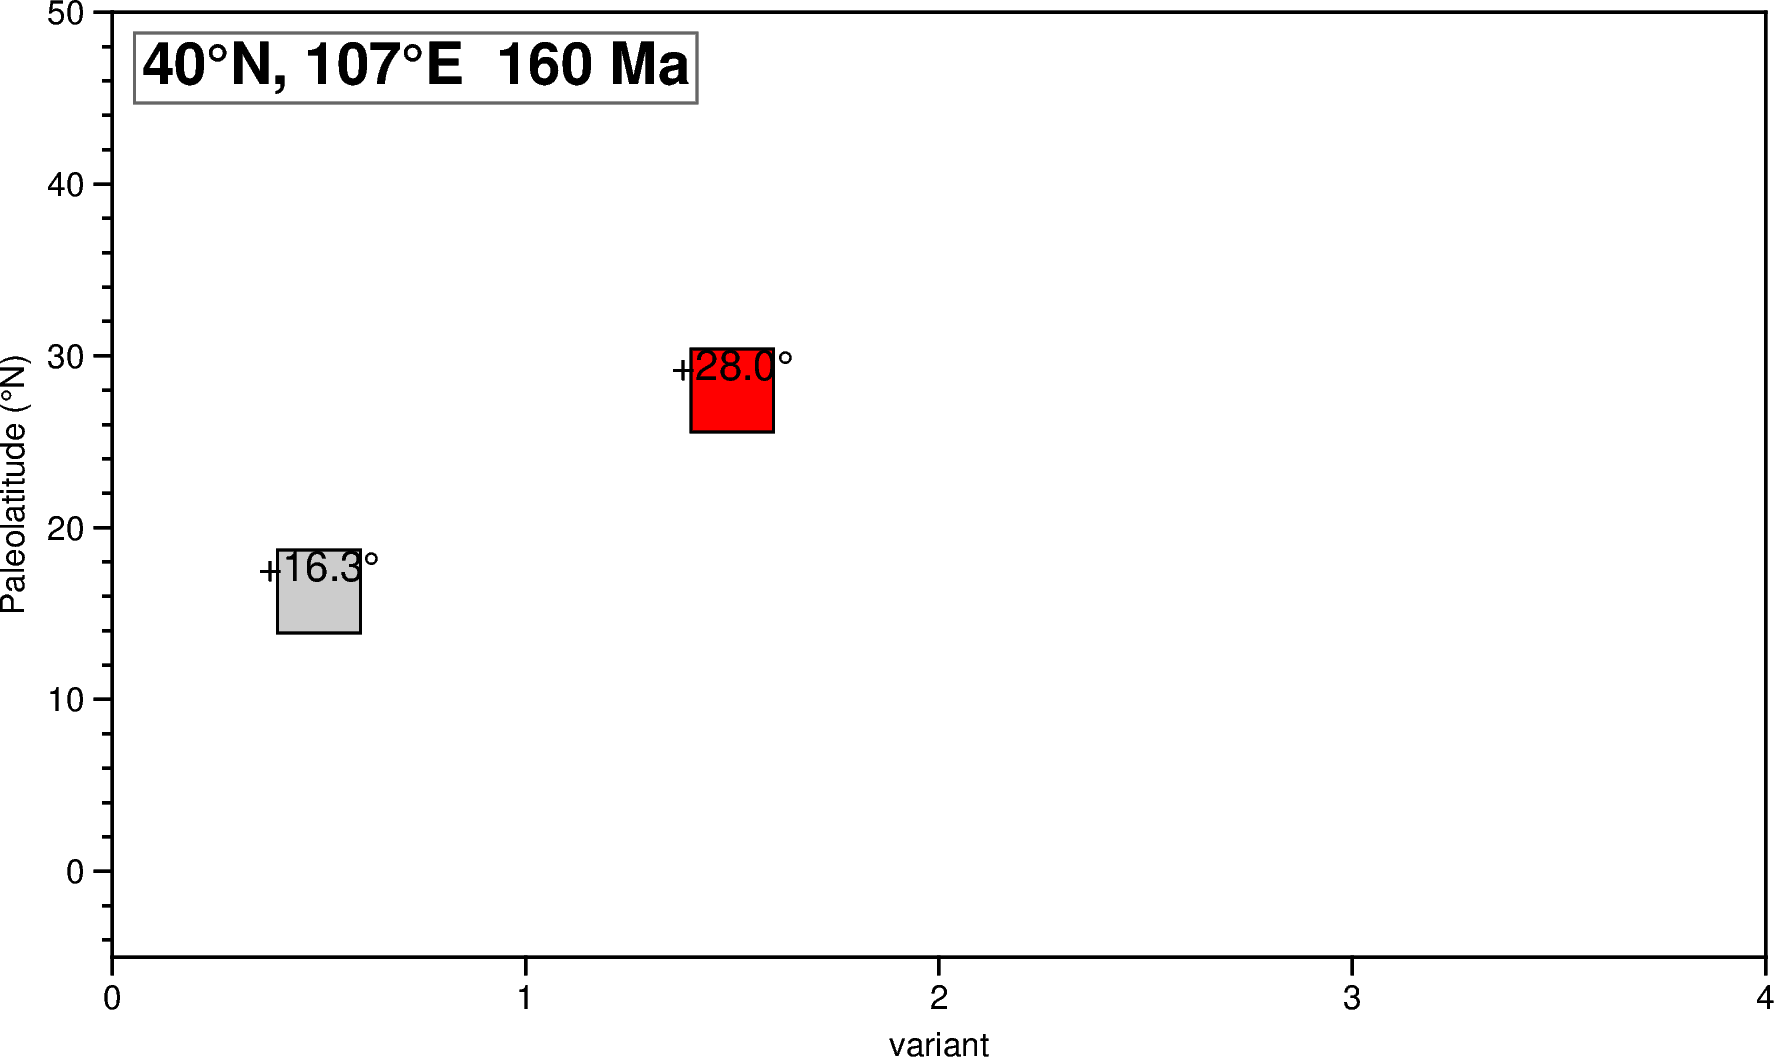

In [6]:
# Cell 5 — bar comparison
labels = ["uncorrected", "SVEI-corrected", "reconstruction", "residual"]
values = [paleolat_uncorr, paleolat_corr, paleolat_recon, paleolat_corr - paleolat_recon]
fills  = ["gray80",     "red",            "gray40",         "black"]

fig = pygmt.Figure()
fig.basemap(region=[0, 4, -5, 50], projection="X14c/8c",
            frame=["xa1+lvariant", "yaf+lPaleolatitude (°N)", "WSrt"])
for i, (lab, val, col) in enumerate(zip(labels, values, fills)):
    fig.plot(x=[i + 0.5], y=[val], style="r0.7c", fill=col, pen="0.6p,black")
    fig.text(x=[i + 0.5], y=[val + 1.5], text=f"{val:+.1f}°", font="10p")

fig.text(text=f"{SITE_LON_LAT[1]:.0f}°N, {SITE_LON_LAT[0]:.0f}°E @ {ROCK_AGE_MA:.0f} Ma",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=900)
display(HTML('<div style="height:1cm"></div>'))


## What the figure shows

A four-bar comparison of paleolatitude estimates for the same Junggar sedimentary site at 160 Ma:

- **uncorrected (gray)** — paleolatitude implied by the raw Fisher-mean inclination, before any shallowing correction. Typically ~16°N for these red beds.
- **King-corrected (red)** — paleolatitude after applying `tan(I_corr) = tan(I_obs) / f` with the Gilder et al. (2001) published `f = 0.55`. The correction lifts paleolat by ~12° to ~28°N — a large bias that dominates any plate-model-vs-data comparison if ignored.
- **reconstruction (dark gray)** — paleolatitude predicted by `gplately.Points.reconstruct()` at the rock age in Cao 2024.
- **residual (black)** — `corrected − reconstruction`. A residual within ~5° is consistent with the plate model; larger residuals would point to either model-fit issues at this age in Cao 2024 or a true tectonic motion (vertical-axis rotation, paleomag-frame deviation) that the simple dipole comparison cannot resolve.

The takeaway is that the shallowing correction is the largest single source of bias in raw sedimentary paleomagnetic data — the gap between the gray and red bars is much larger than the gap between the red and dark-gray bars, even before any plate-model details are debated.


## Extend this

- **Swap plate models.** Re-run with `MODEL_NAME = "Zahirovic2022"` or `"Merdith2021"`. The reconstruction-predicted paleolatitude depends on which model you trust; if the SVEI-corrected paleolatitude lies between two models, you have a discriminator.
- **Sweep the rock age.** Many of the sedimentary datasets span a stratigraphic interval. Sweep `ROCK_AGE_MA` across the interval and plot how the reconstruction-predicted paleolatitude evolves.
- **Different dataset.** SVEI works on any sedimentary collection. Re-run with the Linnaeite Range or Yangtze Block compilations.
- **Cross-reference T28.** The Osler case in T28 is the *rigid-block* analogue of this notebook — paleomagnetic pole versus reconstruction prediction. T30 is the sedimentary, inclination-only version of the same test.

## References

- Tauxe, L., Heslop, D. & Gilder, S. (2024). SVEI: Statistical Variation of Effective Inclination for the geocentric-axial-dipole assumption. *Earth and Planetary Science Letters* (in press).
- Gilder, S., Chen, Y. & Sen, S. (2001). Oligo-Miocene magnetostratigraphy and rock magnetism of the Xishuigou section, Subei (Gansu Province, western China) and implications for shallow inclinations in central Asia. *J. Geophys. Res.* 106, 30505–30521.
- King, R.F. (1955). The remanent magnetism of artificially deposited sediments. *Mon. Not. R. Astron. Soc.* 7, 115–134.
- Cao, X. et al. (2024). *Earth System Science Data* 16, 4007–4032.
- Mather, B.R. et al. (2024). *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
